# Simulated Annealing Benchmark

This notebook compares two ways of spending the same simulated annealing budget on randomly generated QUBO instances.


In [1]:
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import scipy.sparse as sp

current_dir = os.getcwd() 

root_path = os.path.abspath(os.path.join(current_dir, '..'))

if root_path not in sys.path:
    sys.path.insert(0, root_path)
from problem.qubo_problem import QuboProblem
from solver.classical_solver.simulated_annealing import SimulatedAnnealing
from data_loaders import save_instances
from utils.display_methods import plot_benchmark_comparison


In [2]:
def create_random_qubo(size, density=0.1):
    # Generate a random sparse matrix
    random_matrix = sp.random(size, size, density=density, format='csr')
    random_matrix.data -= 0.5
    Q_data = sp.triu(random_matrix, format='csr')
    return QuboProblem(Q_data)


In [3]:
# Prepare benchmark data
N = 300
instances = [create_random_qubo(N) for _ in range(5)] 

def run_benchmark():
    results = []
    
    for idx, qubo in enumerate(instances):
        print(f"Testing Instance {idx}...")
        
        # Stratégie A : Une seule exécution longue et lente
        sa_long = SimulatedAnnealing(initial_temp=1000, steps_per_temp=1000, decreasing_factor=0.99)
        _, cost_long = sa_long.solve_efficient(qubo)
        
        # Stratégie B : Plusieurs exécutions courtes et rapides
        sa_short = SimulatedAnnealing(initial_temp=1000, steps_per_temp=100, decreasing_factor=0.95)
        
        short_run_results = []
        for _ in range(10):
            _, cost = sa_short.solve_efficient(qubo)
            short_run_results.append(cost)
        
        cost_best_of_short = min(short_run_results)
        
        results.append({
            'Instance': idx,
            'Long_Run_Cost': cost_long,
            'Best_of_Short_Runs': cost_best_of_short,
            'Short_Runs_Std': np.std(short_run_results)
        })
        
    return pd.DataFrame(results)

# Exécution
df_benchmark = run_benchmark()
display(df_benchmark)


Testing Instance 0...
Testing Instance 1...
Testing Instance 2...
Testing Instance 3...
Testing Instance 4...


,Instance,Long_Run_Cost,Best_of_Short_Runs,Short_Runs_Std
0,0,-32783.685665,-860.613128,68.720139
1,1,-25345.246230,-817.591777,92.410012
2,2,-48181.558150,-1055.976104,58.022935
3,3,-14298.083005,-585.682263,65.141019
4,4,-47664.885725,-1117.261926,124.602417


<Axes: title={'center': 'Resource Efficiency Benchmark: Long Run vs Short Runs'}, ylabel='Energy (lower is better)'>

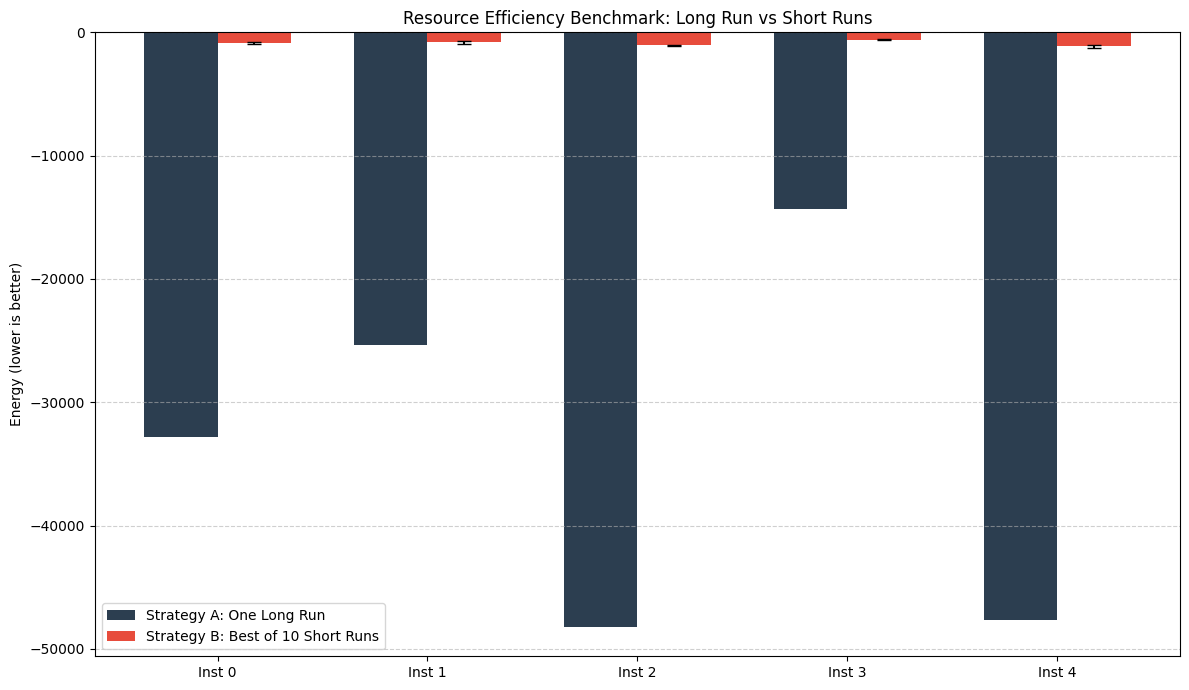

In [4]:

save_instances(instances)

plot_benchmark_comparison(df_benchmark)


The results are extremely significant. The "One Long Run" strategy achieves costs that are roughly 30 to 40 times lower than the "Best of 10 Short Runs," even though they use the same total iteration budget.